In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


'Colab Notebooks'			 'Payments Screenshot'
 flowerdatabase.zip			 'Product Image'
'Khaki Payment Screenshot Upload.gform'  'Untitled form.gform'
'Payment Screenshots.gsheet'


In [ ]:
!cp "/content/drive/MyDrive/flowerdatabase.zip" /content/

cp: cannot stat '/content/drive/MyDrive/flowerdatabase.zip': No such file or directory


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/flowerdatabase.zip"
extract_path = "/content/drive/MyDrive/flower"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense , Conv2D , MaxPooling2D , Flatten , BatchNormalization , Dropout

In [ ]:
import os
import shutil
import random
from pathlib import Path

# =========================
# CONFIGURATION
# =========================

SOURCE_DIR = "/content/drive/MyDrive/flower/database"
OUTPUT_DIR = "/content/drive/MyDrive/flower/mango_dataset"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42

# Make results reproducible
random.seed(SEED)

# =========================
# CLASS NAMES
# =========================

classes = [
    "healthy",
    "anthracnose",
    "mango malformation",
    "powdery mildew",
    "anthracnose & powdery mildew",
    "anthracnose & mango malformation",
    "mango malformation & powdery mildew"
]

# =========================
# CREATE DIRECTORIES
# =========================

splits = ["train", "validation", "test"]

for split in splits:
    for class_name in classes:
        os.makedirs(
            os.path.join(OUTPUT_DIR, split, class_name),
            exist_ok=True
        )

# =========================
# SPLIT DATASET
# =========================

for class_name in classes:

    class_path = os.path.join(SOURCE_DIR, class_name)

    if not os.path.exists(class_path):
        print(f"WARNING: Folder not found -> {class_path}")
        continue

    # Get image files
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    # Shuffle images
    random.shuffle(images)

    total = len(images)

    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    print(f"\n{class_name}")
    print(f"Total      : {total}")
    print(f"Train      : {len(train_images)}")
    print(f"Validation : {len(val_images)}")
    print(f"Test       : {len(test_images)}")

    # Copy files
    for image in train_images:
        shutil.copy2(
            os.path.join(class_path, image),
            os.path.join(OUTPUT_DIR, "train", class_name, image)
        )

    for image in val_images:
        shutil.copy2(
            os.path.join(class_path, image),
            os.path.join(OUTPUT_DIR, "validation", class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(class_path, image),
            os.path.join(OUTPUT_DIR, "test", class_name, image)
        )

print("\nDataset splitting completed!")


healthy
Total      : 219
Train      : 153
Validation : 32
Test       : 34

anthracnose
Total      : 209
Train      : 146
Validation : 31
Test       : 32

mango malformation
Total      : 112
Train      : 78
Validation : 16
Test       : 18

powdery mildew
Total      : 173
Train      : 121
Validation : 25
Test       : 27

anthracnose & powdery mildew
Total      : 184
Train      : 128
Validation : 27
Test       : 29

anthracnose & mango malformation
Total      : 25
Train      : 17
Validation : 3
Test       : 5

mango malformation & powdery mildew
Total      : 35
Train      : 24
Validation : 5
Test       : 6

Dataset splitting completed!


In [ ]:
# import shutil
# import os

# path = "/content/drive/MyDrive/flower/mango_dataset"

# if os.path.exists(path):
#     shutil.rmtree(path)
#     print("Old mango_dataset deleted successfully.")
# else:
#     print("mango_dataset does not exist.")

Old mango_dataset deleted successfully.


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/flower/mango_dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/flower/mango_dataset/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/flower/mango_dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

print("Classes:")
print(train_ds.class_names)

Found 667 files belonging to 7 classes.
Found 139 files belonging to 7 classes.
Found 151 files belonging to 7 classes.
Classes:
['anthracnose', 'anthracnose & mango malformation', 'anthracnose & powdery mildew', 'healthy', 'mango malformation', 'mango malformation & powdery mildew', 'powdery mildew']


In [ ]:
import os

path = "/content/drive/MyDrive/flower/mango_dataset/test/anthracnose"

print("Folder exists:", os.path.exists(path))
print("Number of files:", len(os.listdir(path)))

print("\nFirst 5 files:")
print(os.listdir(path)[:5])

Folder exists: True
Number of files: 32

First 5 files:
['IMG_20260207_152012309_HDR_AE.jpg', 'IMG_20260207_152112384_HDR_AE.jpg', 'IMG_20260207_152121560_HDR_AE.jpg', 'IMG_20260207_155721534_HDR_AE.jpg', 'IMG_20260207_155705650_HDR_AE.jpg']


In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.10),
], name="data_augmentation")

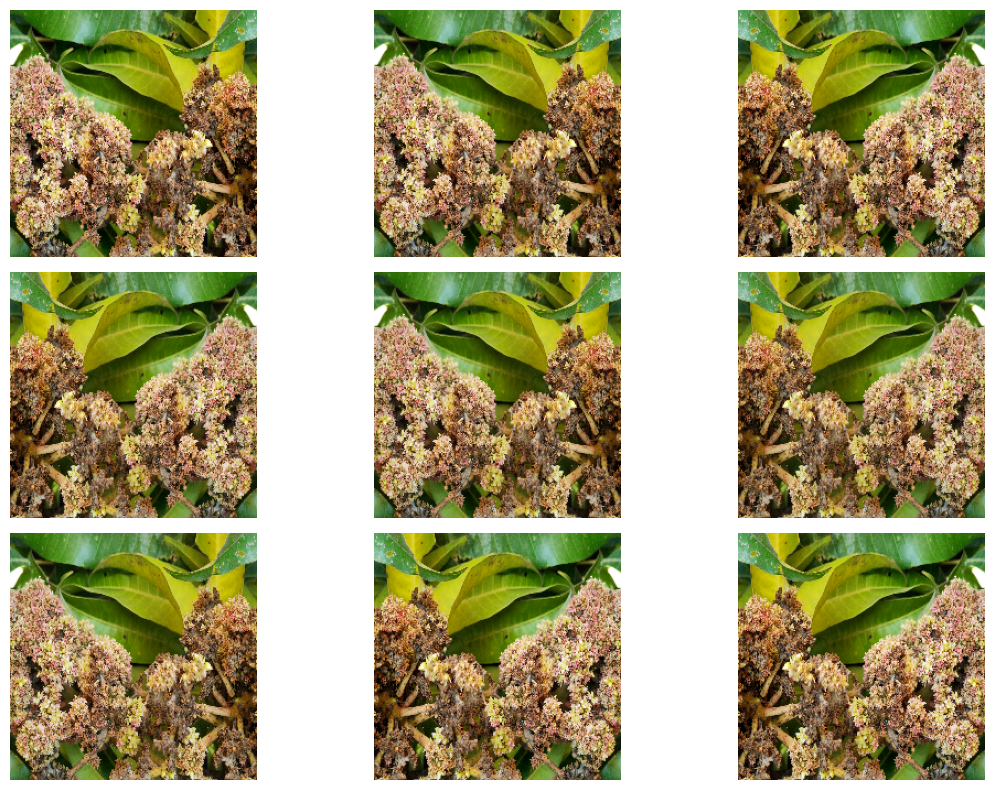

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

images, labels = next(iter(train_ds))

image = images[0]

plt.figure(figsize=(12, 8))

for i in range(9):

    augmented_image = data_augmentation(
        tf.expand_dims(image, axis=0),
        training=True
    )[0]

    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(tf.cast(augmented_image, tf.uint8))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

SOURCE_TRAIN = "/content/drive/MyDrive/flower/mango_dataset/train"
BALANCED_TRAIN = "/content/drive/MyDrive/flower/mango_dataset/train_balanced"

# Remove old balanced folder if it exists
if os.path.exists(BALANCED_TRAIN):
    shutil.rmtree(BALANCED_TRAIN)

# Copy the complete original training folder
shutil.copytree(SOURCE_TRAIN, BALANCED_TRAIN)

print("Original training set copied to train_balanced.")

Original training set copied to train_balanced.


In [ ]:
import os
import random
from PIL import Image, ImageEnhance, ImageOps

# ==============================
# CONFIGURATION
# ==============================

TRAIN_DIR = "/content/drive/MyDrive/flower/mango_dataset/train_balanced"

TARGET_IMAGES = 200
SEED = 42

random.seed(SEED)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")

# ==============================
# AUGMENTATION FUNCTION
# ==============================

def augment_image(image):

    # Random horizontal flip
    if random.random() < 0.5:
        image = ImageOps.mirror(image)

    # Random contrast
    contrast_factor = random.uniform(0.90, 1.10)
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(contrast_factor)

    return image


# ==============================
# PROCESS EACH CLASS
# ==============================

for class_name in sorted(os.listdir(TRAIN_DIR)):

    class_dir = os.path.join(TRAIN_DIR, class_name)

    if not os.path.isdir(class_dir):
        continue

    # Only use ORIGINAL images as sources
    # Never use previously generated aug_ images
    original_images = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(IMAGE_EXTENSIONS)
        and not f.startswith("aug_")
    ]

    current_count = len(original_images)

    print(f"\nClass: {class_name}")
    print(f"Original images: {current_count}")

    if current_count >= TARGET_IMAGES:
        print("Already has 200 or more. No augmentation needed.")
        continue

    images_needed = TARGET_IMAGES - current_count

    print(f"Generating: {images_needed} augmented images")

    for i in range(images_needed):

        # Randomly select one ORIGINAL image
        source_name = random.choice(original_images)
        source_path = os.path.join(class_dir, source_name)

        # Open image
        image = Image.open(source_path).convert("RGB")

        # Apply augmentation
        augmented = augment_image(image)

        # Create unique filename
        output_name = f"aug_{i+1:04d}_{source_name.rsplit('.', 1)[0]}.jpg"
        output_path = os.path.join(class_dir, output_name)

        # Save
        augmented.save(
            output_path,
            format="JPEG",
            quality=95
        )

    final_count = len([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ])

    print(f"Final images: {final_count}")

print("\n===================================")
print("PHYSICAL AUGMENTATION COMPLETED")
print("===================================")


Class: anthracnose
Original images: 146
Generating: 54 augmented images
Final images: 200

Class: anthracnose & mango malformation
Original images: 17
Generating: 183 augmented images
Final images: 200

Class: anthracnose & powdery mildew
Original images: 128
Generating: 72 augmented images
Final images: 200

Class: healthy
Original images: 153
Generating: 47 augmented images
Final images: 200

Class: mango malformation
Original images: 78
Generating: 122 augmented images
Final images: 200

Class: mango malformation & powdery mildew
Original images: 24
Generating: 176 augmented images
Final images: 200

Class: powdery mildew
Original images: 121
Generating: 79 augmented images
Final images: 200

PHYSICAL AUGMENTATION COMPLETED


In [ ]:
import os

TRAIN_DIR = "/content/drive/MyDrive/flower/mango_dataset/train_balanced"

print("FINAL TRAINING DISTRIBUTION\n")

total = 0

for class_name in sorted(os.listdir(TRAIN_DIR)):

    class_dir = os.path.join(TRAIN_DIR, class_name)

    if os.path.isdir(class_dir):

        count = len([
            f for f in os.listdir(class_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ])

        print(f"{class_name:45s} : {count}")

        total += count

print("\nTotal training images:", total)

FINAL TRAINING DISTRIBUTION

anthracnose                                   : 200
anthracnose & mango malformation              : 200
anthracnose & powdery mildew                  : 200
healthy                                       : 200
mango malformation                            : 200
mango malformation & powdery mildew           : 200
powdery mildew                                : 200

Total training images: 1400


In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/flower/mango_dataset/train_balanced',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=42
)

Found 1400 files belonging to 7 classes.


In [ ]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/flower/mango_dataset/validation',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    shuffle=False
)

Found 139 files belonging to 7 classes.


In [ ]:
test_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/flower/mango_dataset/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    shuffle=False
)

Found 151 files belonging to 7 classes.


In [ ]:
print("Classes:", train_ds.class_names)
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Classes: ['anthracnose', 'anthracnose & mango malformation', 'anthracnose & powdery mildew', 'healthy', 'mango malformation', 'mango malformation & powdery mildew', 'powdery mildew']
Training batches: 44
Validation batches: 5
Test batches: 5


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [ ]:
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(256, 256, 3)
)

base_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = keras.Sequential()

model.add(keras.Input(shape=(256, 256, 3)))

model.add(data_augmentation)

model.add(base_model)

model.add(keras.layers.GlobalAveragePooling2D())

model.add(keras.layers.Dropout(0.3))

model.add(keras.layers.Dense(128, activation='relu'))

model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Dense(7, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,084,183 (23.21 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/flower/mango_dataset/models/best_phase2_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
# import os

# os.makedirs(
#     '/content/drive/MyDrive/flower/mango_dataset/models',
#     exist_ok=True
# )

In [ ]:
# import tensorflow as tf
# from tensorflow import keras

# model_path = "/content/drive/MyDrive/flower/mango_dataset/models/best_phase1_model.keras"

# model = keras.models.load_model(model_path)

# print("Saved model loaded successfully.")
# print("Output shape:", model.output_shape)

Saved model loaded successfully.
Output shape: (None, 7)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,084,183 (23.21 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
# import os
# import tensorflow as tf
# from tensorflow import keras

# # =========================================================
# # 1. LOAD THE SAVED BEST MODEL
# # =========================================================

# old_model_path = "/content/drive/MyDrive/flower/mango_dataset/models/best_phase1_model.keras"

# model = keras.models.load_model(old_model_path)

# print("Saved model loaded.")
# print("Output shape:", model.output_shape)


# # =========================================================
# # 2. COMPILE THE MODEL
# # =========================================================

# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     metrics=["accuracy"]
# )

# print("Model compiled.")


# # =========================================================
# # 3. CREATE NEW CHECKPOINT PATHS
# # =========================================================

# model_dir = "/content/drive/MyDrive/flower/mango_dataset/models"

# os.makedirs(model_dir, exist_ok=True)

# best_model_path = os.path.join(
#     model_dir,
#     "best_phase1_recovered.keras"
# )

# latest_model_path = os.path.join(
#     model_dir,
#     "latest_phase1_recovered.keras"
# )


# # =========================================================
# # 4. CALLBACKS
# # =========================================================

# early_stopping = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor="val_loss",
#     factor=0.2,
#     patience=2,
#     min_lr=1e-6,
#     verbose=1
# )

# # Save only the best validation model
# best_checkpoint = keras.callbacks.ModelCheckpoint(
#     best_model_path,
#     monitor="val_loss",
#     save_best_only=True,
#     verbose=1
# )

# # Save the latest completed epoch
# latest_checkpoint = keras.callbacks.ModelCheckpoint(
#     latest_model_path,
#     monitor="val_loss",
#     save_best_only=False,
#     verbose=0
# )


# # =========================================================
# # 5. CONTINUE TRAINING
# # =========================================================

# history_recovered = model.fit(
#     train_ds,
#     validation_data=validation_ds,
#     epochs=12,
#     callbacks=[
#         early_stopping,
#         reduce_lr,
#         best_checkpoint,
#         latest_checkpoint
#     ]
# )

Saved model loaded.
Output shape: (None, 7)
Model compiled.
Epoch 1/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9179 - loss: 0.1914 
Epoch 1: val_loss improved from None to 0.48445, saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_phase1_recovered.keras

Epoch 1: finished saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_phase1_recovered.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 566s 12s/step - accuracy: 0.9186 - loss: 0.2140 - val_accuracy: 0.8273 - val_loss: 0.4844 - learning_rate: 0.0010
Epoch 2/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9351 - loss: 0.1768
Epoch 2: val_loss did not improve from 0.48445
44/44 ━━━━━━━━━━━━━━━━━━━━ 326s 7s/step - accuracy: 0.9314 - loss: 0.1927 - val_accuracy: 0.8417 - val_loss: 0.4850 - learning_rate: 0.0010
Epoch 3/12
 9/44 ━━━━━━━━━━━━━━━━━━━━ 4:19 7s/step - accuracy: 0.9443 - loss: 0.1755

KeyboardInterrupt: 

In [ ]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=8,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 359s 8s/step - accuracy: 0.8929 - loss: 0.2593 - val_accuracy: 0.8633 - val_loss: 0.4649 - learning_rate: 1.6000e-06
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 378s 9s/step - accuracy: 0.9236 - loss: 0.2359 - val_accuracy: 0.8633 - val_loss: 0.4650 - learning_rate: 1.6000e-06
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 344s 8s/step - accuracy: 0.9250 - loss: 0.2419 - val_accuracy: 0.8633 - val_loss: 0.4651 - learning_rate: 1.0000e-06
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 381s 8s/step - accuracy: 0.9214 - loss: 0.2381 - val_accuracy: 0.8633 - val_loss: 0.4651 - learning_rate: 1.0000e-06
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 376s 8s/step - accuracy: 0.9264 - loss: 0.2265 - val_accuracy: 0.8633 - val_loss: 0.4651 - learning_rate: 1.0000e-06


In [ ]:
import os

model_dir = "/content/drive/MyDrive/flower/mango_dataset/models"

for file in os.listdir(model_dir):
    print(file)

best_phase1_model.keras
best_phase1_recovered.keras
latest_phase1_recovered.keras
best_phase2_model.keras


In [ ]:
import os
import tensorflow as tf
from tensorflow import keras

model_dir = "/content/drive/MyDrive/flower/mango_dataset/models"

model_files = [
    "best_phase1_model.keras",
    "best_phase1_recovered.keras",
    "latest_phase1_recovered.keras",
    "best_phase2_model.keras"
]

results = {}

for filename in model_files:

    path = os.path.join(model_dir, filename)

    print("\n" + "="*60)
    print("Evaluating:", filename)
    print("="*60)

    saved_model = keras.models.load_model(path)

    loss, accuracy = saved_model.evaluate(
        validation_ds,
        verbose=1
    )

    results[filename] = {
        "val_loss": loss,
        "val_accuracy": accuracy
    }

    print("Validation Loss    :", loss)
    print("Validation Accuracy:", accuracy)


Evaluating: best_phase1_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 105s 16s/step - accuracy: 0.8633 - loss: 0.4627
Validation Loss    : 0.46271997690200806
Validation Accuracy: 0.8633093237876892

Evaluating: best_phase1_recovered.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.8273 - loss: 0.4844
Validation Loss    : 0.4844454824924469
Validation Accuracy: 0.8273381590843201

Evaluating: latest_phase1_recovered.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.8417 - loss: 0.4850
Validation Loss    : 0.48504090309143066
Validation Accuracy: 0.8417266011238098

Evaluating: best_phase2_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.8489 - loss: 0.4635
Validation Loss    : 0.4634958803653717
Validation Accuracy: 0.8489208817481995


In [ ]:
best_model = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_phase1_model.keras"
)

print("Best model loaded successfully.")
print("Output shape:", best_model.output_shape)

Best model loaded successfully.
Output shape: (None, 7)


In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Get true labels
y_true = np.concatenate([
    y.numpy() for x, y in validation_ds
])

# Get predicted probabilities
y_prob = best_model.predict(validation_ds)

# Convert probabilities to predicted class
y_pred = np.argmax(y_prob, axis=1)

# Class names
class_names = validation_ds.class_names

print("Number of validation samples:", len(y_true))
print("Number of predictions:", len(y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

print("Macro Precision:",
      precision_score(y_true, y_pred, average='macro'))

print("Macro Recall:",
      recall_score(y_true, y_pred, average='macro'))

print("Macro F1:",
      f1_score(y_true, y_pred, average='macro'))

print("Weighted F1:",
      f1_score(y_true, y_pred, average='weighted'))

5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 12s/step
Number of validation samples: 139
Number of predictions: 139

Classification Report:
                                     precision    recall  f1-score   support

                        anthracnose     0.8857    1.0000    0.9394        31
   anthracnose & mango malformation     0.6667    0.6667    0.6667         3
       anthracnose & powdery mildew     0.7778    0.7778    0.7778        27
                            healthy     0.9688    0.9688    0.9688        32
                 mango malformation     0.9286    0.8125    0.8667        16
mango malformation & powdery mildew     0.6667    0.4000    0.5000         5
                     powdery mildew     0.8000    0.8000    0.8000        25

                           accuracy                         0.8633       139
                          macro avg     0.8134    0.7751    0.7885       139
                       weighted avg     0.8608    0.8633    0.8596       139

Macro Precision: 0.81344954

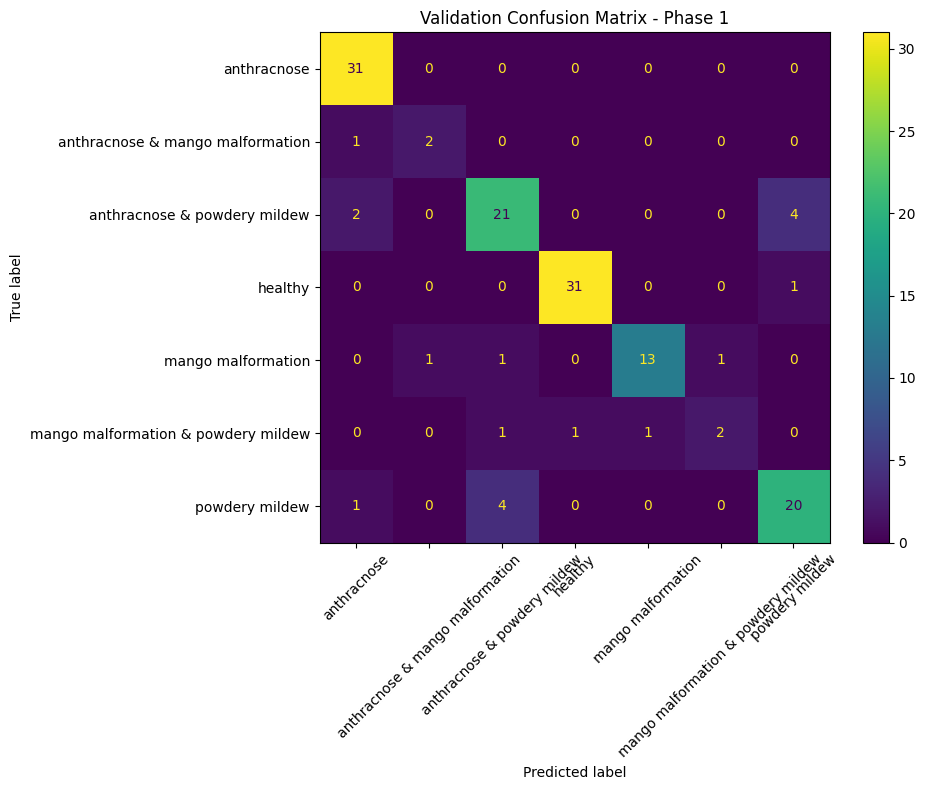

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format='d'
)

plt.title("Validation Confusion Matrix - Phase 1")
plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step


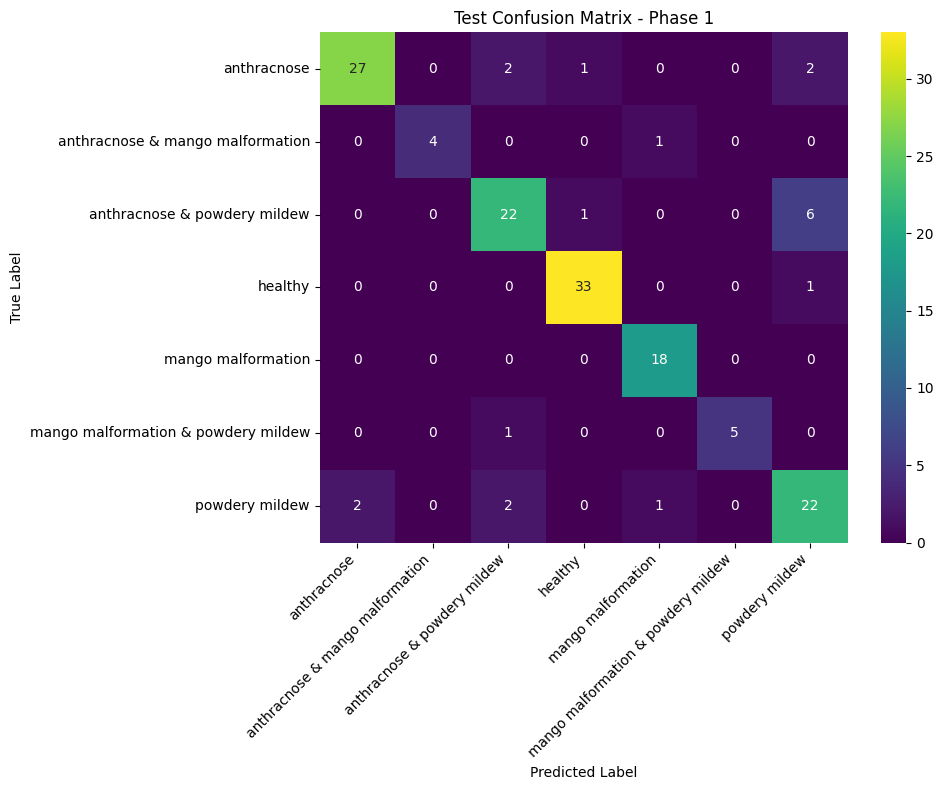

In [ ]:
##confusion matrix for test set of phase 1 needs to be executed

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras

# Load our best Phase 1 model
phase1_model = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_phase1_model.keras"
)

# Get true labels
y_true = np.concatenate([
    y.numpy() for x, y in test_ds
])

# Get predictions
y_prob = phase1_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

# Class names
class_names = test_ds.class_names

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Test Confusion Matrix - Phase 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
best_model = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_phase1_model.keras"
)

base_model = best_model.get_layer("efficientnetv2-b0")

print("Total EfficientNet layers:", len(base_model.layers))

Total EfficientNet layers: 270


In [ ]:
for i, layer in enumerate(base_model.layers[-40:], start=len(base_model.layers)-40):
    print(i, layer.name, layer.__class__.__name__)

230 block6f_se_reduce Conv2D
231 block6f_se_expand Conv2D
232 block6f_se_excite Multiply
233 block6f_project_conv Conv2D
234 block6f_project_bn BatchNormalization
235 block6f_drop Dropout
236 block6f_add Add
237 block6g_expand_conv Conv2D
238 block6g_expand_bn BatchNormalization
239 block6g_expand_activation Activation
240 block6g_dwconv2 DepthwiseConv2D
241 block6g_bn BatchNormalization
242 block6g_activation Activation
243 block6g_se_squeeze GlobalAveragePooling2D
244 block6g_se_reshape Reshape
245 block6g_se_reduce Conv2D
246 block6g_se_expand Conv2D
247 block6g_se_excite Multiply
248 block6g_project_conv Conv2D
249 block6g_project_bn BatchNormalization
250 block6g_drop Dropout
251 block6g_add Add
252 block6h_expand_conv Conv2D
253 block6h_expand_bn BatchNormalization
254 block6h_expand_activation Activation
255 block6h_dwconv2 DepthwiseConv2D
256 block6h_bn BatchNormalization
257 block6h_activation Activation
258 block6h_se_squeeze GlobalAveragePooling2D
259 block6h_se_reshape Resh

In [ ]:
best_model = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_phase1_model.keras"
)

base_model = best_model.get_layer("efficientnetv2-b0")

print("EfficientNet layers:", len(base_model.layers))

EfficientNet layers: 270


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

In [ ]:
trainable_layers = [
    layer for layer in base_model.layers
    if layer.trainable
]

print("Trainable EfficientNet layers:", len(trainable_layers))

for layer in trainable_layers:
    print(layer.name, layer.__class__.__name__)

Trainable EfficientNet layers: 32
block6f_se_reduce Conv2D
block6f_se_expand Conv2D
block6f_se_excite Multiply
block6f_project_conv Conv2D
block6f_drop Dropout
block6f_add Add
block6g_expand_conv Conv2D
block6g_expand_activation Activation
block6g_dwconv2 DepthwiseConv2D
block6g_activation Activation
block6g_se_squeeze GlobalAveragePooling2D
block6g_se_reshape Reshape
block6g_se_reduce Conv2D
block6g_se_expand Conv2D
block6g_se_excite Multiply
block6g_project_conv Conv2D
block6g_drop Dropout
block6g_add Add
block6h_expand_conv Conv2D
block6h_expand_activation Activation
block6h_dwconv2 DepthwiseConv2D
block6h_activation Activation
block6h_se_squeeze GlobalAveragePooling2D
block6h_se_reshape Reshape
block6h_se_reduce Conv2D
block6h_se_expand Conv2D
block6h_se_excite Multiply
block6h_project_conv Conv2D
block6h_drop Dropout
block6h_add Add
top_conv Conv2D
top_activation Activation


In [ ]:
print(
    "Total trainable parameters:",
    sum(
        keras.backend.count_params(w)
        for w in best_model.trainable_weights
    )
)

print(
    "Total non-trainable parameters:",
    sum(
        keras.backend.count_params(w)
        for w in best_model.non_trainable_weights
    )
)

Total trainable parameters: 1872663
Total non-trainable parameters: 4211520


In [ ]:
best_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
phase2_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_phase2_finetuned_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
phase2_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

phase2_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [ ]:
history_phase2 = best_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[
        phase2_early_stopping,
        phase2_reduce_lr,
        phase2_checkpoint
    ]
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 769s 17s/step - accuracy: 0.9479 - loss: 0.1611 - val_accuracy: 0.8489 - val_loss: 0.4655 - learning_rate: 1.0000e-05
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 368s 8s/step - accuracy: 0.9543 - loss: 0.1591 - val_accuracy: 0.8489 - val_loss: 0.4704 - learning_rate: 1.0000e-05
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 390s 9s/step - accuracy: 0.9521 - loss: 0.1595 - val_accuracy: 0.8561 - val_loss: 0.4739 - learning_rate: 1.0000e-05
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 362s 8s/step - accuracy: 0.9450 - loss: 0.1567 - val_accuracy: 0.8561 - val_loss: 0.4739 - learning_rate: 2.0000e-06
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 402s 8s/step - accuracy: 0.9450 - loss: 0.1606 - val_accuracy: 0.8561 - val_loss: 0.4725 - learning_rate: 2.0000e-06


In [ ]:
phase2_model = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_phase2_finetuned_model.keras"
)

print("Phase-2 model loaded successfully.")
print("Output shape:", phase2_model.output_shape)

Phase-2 model loaded successfully.
Output shape: (None, 7)


In [ ]:
import numpy as np

# True validation labels
y_true_phase2 = np.concatenate([
    y.numpy() for x, y in validation_ds
])

# Predicted probabilities
y_prob_phase2 = phase2_model.predict(validation_ds)

# Predicted class
y_pred_phase2 = np.argmax(y_prob_phase2, axis=1)

class_names = validation_ds.class_names

print("Validation samples:", len(y_true_phase2))
print("Predictions:", len(y_pred_phase2))

5/5 ━━━━━━━━━━━━━━━━━━━━ 64s 7s/step
Validation samples: 139
Predictions: 139


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


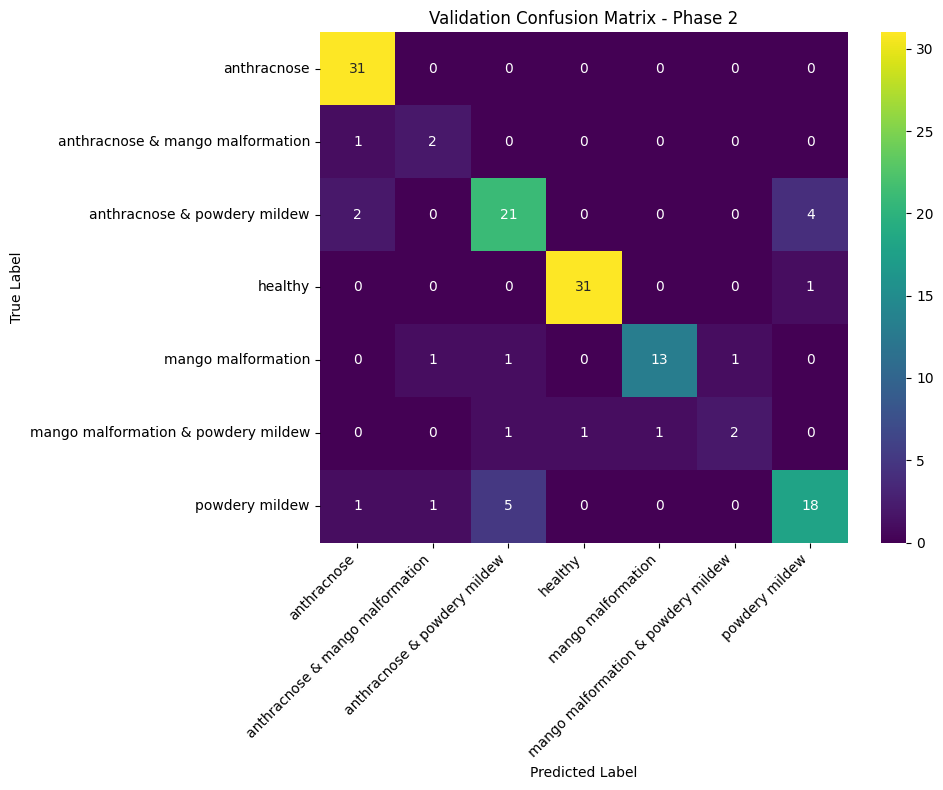

In [ ]:
##Validation Confusion matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# True labels
y_true_val = np.concatenate([
    y.numpy() for x, y in validation_ds
])

# Predicted probabilities
y_prob_val = phase2_model.predict(validation_ds)

# Convert probabilities to predicted class
y_pred_val = np.argmax(y_prob_val, axis=1)

# Class names
class_names = validation_ds.class_names

# Confusion matrix
cm_val = confusion_matrix(y_true_val, y_pred_val)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Validation Confusion Matrix - Phase 2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
## validation classification report

from sklearn.metrics import classification_report

print("Phase 2 Validation Classification Report:\n")

print(
    classification_report(
        y_true_val,
        y_pred_val,
        target_names=class_names,
        digits=4
    )
)

Phase 2 Validation Classification Report:

                                     precision    recall  f1-score   support

                        anthracnose     0.8857    1.0000    0.9394        31
   anthracnose & mango malformation     0.5000    0.6667    0.5714         3
       anthracnose & powdery mildew     0.7500    0.7778    0.7636        27
                            healthy     0.9688    0.9688    0.9688        32
                 mango malformation     0.9286    0.8125    0.8667        16
mango malformation & powdery mildew     0.6667    0.4000    0.5000         5
                     powdery mildew     0.7826    0.7200    0.7500        25

                           accuracy                         0.8489       139
                          macro avg     0.7832    0.7637    0.7657       139
                       weighted avg     0.8487    0.8489    0.8458       139



5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step


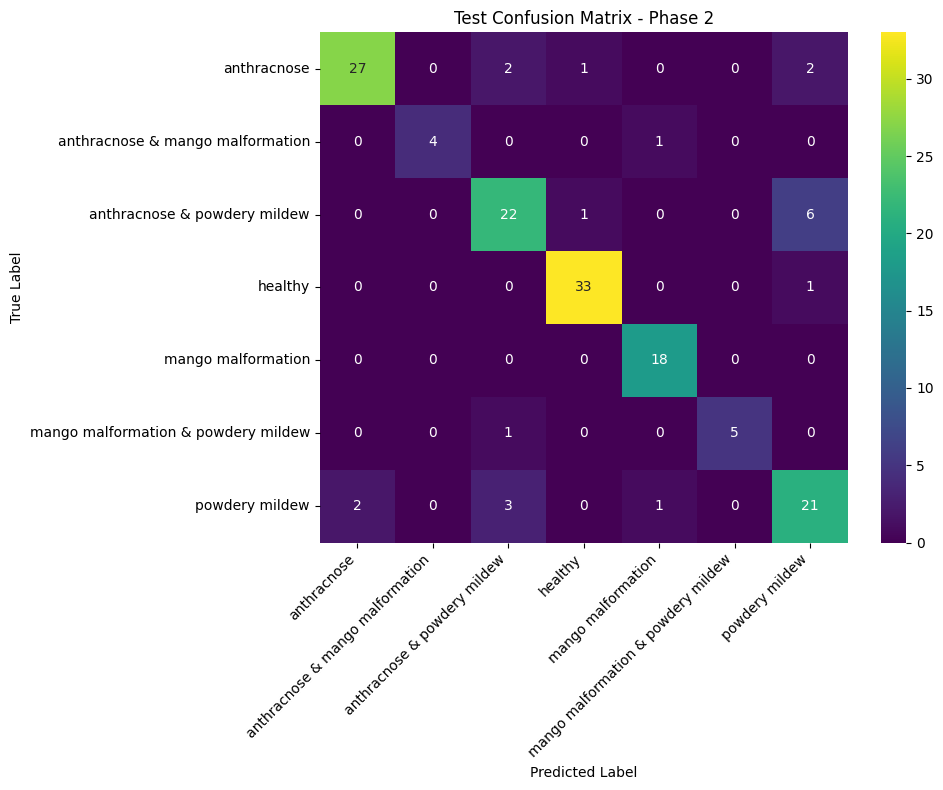

In [ ]:
## Test confusion matrix

# True test labels
y_true_test = np.concatenate([
    y.numpy() for x, y in test_ds
])

# Predicted probabilities
y_prob_test = phase2_model.predict(test_ds)

# Predicted classes
y_pred_test = np.argmax(y_prob_test, axis=1)

# Confusion matrix
cm_test = confusion_matrix(y_true_test, y_pred_test)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Test Confusion Matrix - Phase 2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
##test classification report

print("Phase 2 Test Classification Report:\n")

print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=class_names,
        digits=4
    )
)

Phase 2 Test Classification Report:

                                     precision    recall  f1-score   support

                        anthracnose     0.9310    0.8438    0.8852        32
   anthracnose & mango malformation     1.0000    0.8000    0.8889         5
       anthracnose & powdery mildew     0.7857    0.7586    0.7719        29
                            healthy     0.9429    0.9706    0.9565        34
                 mango malformation     0.9000    1.0000    0.9474        18
mango malformation & powdery mildew     1.0000    0.8333    0.9091         6
                     powdery mildew     0.7000    0.7778    0.7368        27

                           accuracy                         0.8609       151
                          macro avg     0.8942    0.8549    0.8708       151
                       weighted avg     0.8658    0.8609    0.8615       151



In [ ]:
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("PHASE 2 CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true_phase2,
        y_pred_phase2,
        target_names=class_names,
        digits=4
    )
)

print("Macro Precision:",
      precision_score(y_true_phase2, y_pred_phase2, average='macro'))

print("Macro Recall:",
      recall_score(y_true_phase2, y_pred_phase2, average='macro'))

print("Macro F1:",
      f1_score(y_true_phase2, y_pred_phase2, average='macro'))

print("Weighted F1:",
      f1_score(y_true_phase2, y_pred_phase2, average='weighted'))

PHASE 2 CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8857    1.0000    0.9394        31
   anthracnose & mango malformation     0.5000    0.6667    0.5714         3
       anthracnose & powdery mildew     0.7500    0.7778    0.7636        27
                            healthy     0.9688    0.9688    0.9688        32
                 mango malformation     0.9286    0.8125    0.8667        16
mango malformation & powdery mildew     0.6667    0.4000    0.5000         5
                     powdery mildew     0.7826    0.7200    0.7500        25

                           accuracy                         0.8489       139
                          macro avg     0.7832    0.7637    0.7657       139
                       weighted avg     0.8487    0.8489    0.8458       139

Macro Precision: 0.7831872966577935
Macro Recall: 0.7636706349206349
Macro F1: 0.7656965058750773
Weighted F1: 0.8458298

In [ ]:
base_xception = keras.applications.Xception(
    include_top=False,
    weights='imagenet',
    input_shape=(256, 256, 3)
)

base_xception.trainable = False

print("Xception loaded successfully.")
print("Number of layers:", len(base_xception.layers))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Xception loaded successfully.
Number of layers: 132


In [ ]:
xception_preprocess = keras.applications.xception.preprocess_input

In [ ]:
model_xception = keras.Sequential()

model_xception.add(
    keras.Input(shape=(256, 256, 3))
)

model_xception.add(data_augmentation)

model_xception.add(
    keras.layers.Lambda(
        keras.applications.xception.preprocess_input
    )
)

model_xception.add(base_xception)

model_xception.add(
    keras.layers.GlobalAveragePooling2D()
)

model_xception.add(
    keras.layers.Dropout(0.3)
)

model_xception.add(
    keras.layers.Dense(128, activation='relu')
)

model_xception.add(
    keras.layers.Dropout(0.2)
)

model_xception.add(
    keras.layers.Dense(7, activation='softmax')
)

In [ ]:
model_xception.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 8, 8, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,655 (80.58 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
print(
    "Trainable parameters:",
    sum(
        keras.backend.count_params(w)
        for w in model_xception.trainable_weights
    )
)

print(
    "Non-trainable parameters:",
    sum(
        keras.backend.count_params(w)
        for w in model_xception.non_trainable_weights
    )
)

Trainable parameters: 263175
Non-trainable parameters: 20861480


In [ ]:
model_xception.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
xception_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

xception_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

xception_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_xception_phase1.keras",
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
history_xception = model_xception.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=12,
    callbacks=[
        xception_early_stopping,
        xception_reduce_lr,
        xception_checkpoint
    ]
)

Epoch 1/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 760s 16s/step - accuracy: 0.4943 - loss: 1.3621 - val_accuracy: 0.6115 - val_loss: 1.1536 - learning_rate: 0.0010
Epoch 2/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 211s 4s/step - accuracy: 0.6936 - loss: 0.8428 - val_accuracy: 0.6835 - val_loss: 0.9167 - learning_rate: 0.0010
Epoch 3/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.7650 - loss: 0.6646 - val_accuracy: 0.7050 - val_loss: 0.8807 - learning_rate: 0.0010
Epoch 4/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - accuracy: 0.8207 - loss: 0.5401 - val_accuracy: 0.6978 - val_loss: 0.8394 - learning_rate: 0.0010
Epoch 5/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.8300 - loss: 0.4720 - val_accuracy: 0.7194 - val_loss: 0.8400 - learning_rate: 0.0010
Epoch 6/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.8579 - loss: 0.4377 - val_accuracy: 0.6978 - val_loss: 0.8373 - learning_rate: 0.0010
Epoch 7/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 210s 4s/step - accuracy: 0.8543 - loss: 0.4085 - val_ac

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# !nvidia-smi

Fri Sep 11 14:15:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tensorflow import keras

xception_model = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_xception_phase1.keras",
    custom_objects={
        "preprocess_input": keras.applications.xception.preprocess_input
    },
    safe_mode=False
)

print("Xception model loaded successfully.")

Xception model loaded successfully.


5/5 ━━━━━━━━━━━━━━━━━━━━ 321s 58s/step


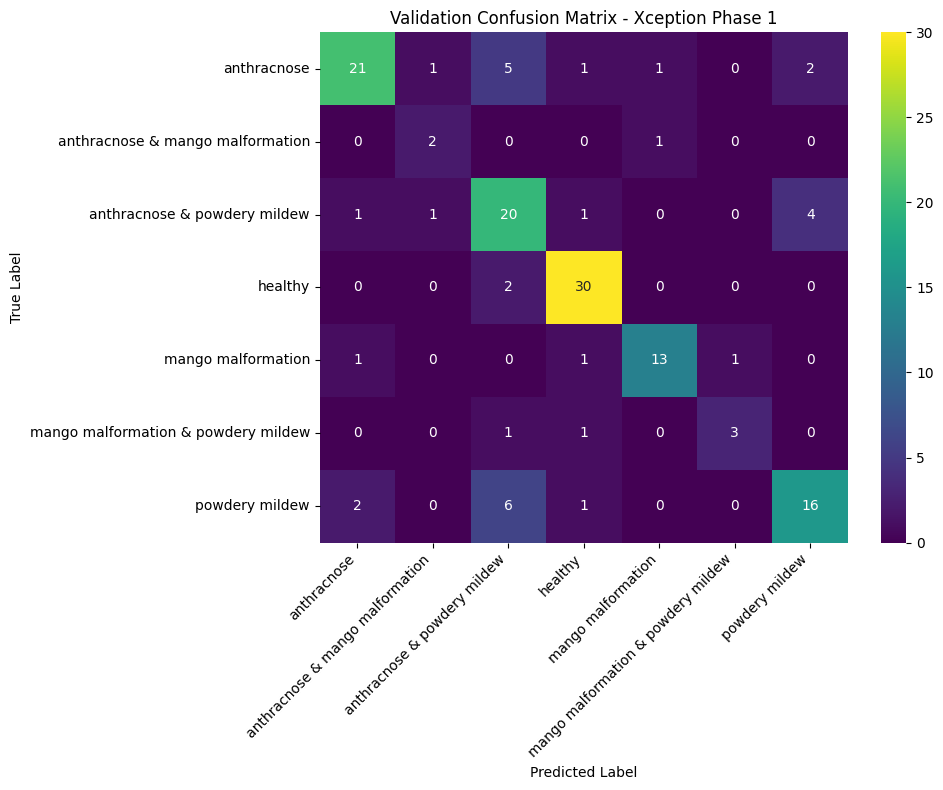

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get true validation labels
y_true_val_xception = np.concatenate([
    y.numpy() for x, y in validation_ds
])

# Get prediction probabilities
y_prob_val_xception = xception_model.predict(validation_ds)

# Convert probabilities to class predictions
y_pred_val_xception = np.argmax(
    y_prob_val_xception,
    axis=1
)

# Class names
class_names = validation_ds.class_names

# Create confusion matrix
cm_val_xception = confusion_matrix(
    y_true_val_xception,
    y_pred_val_xception
)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_val_xception,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Validation Confusion Matrix - Xception Phase 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Xception Phase 1 - Validation Classification Report\n")

print(
    classification_report(
        y_true_val_xception,
        y_pred_val_xception,
        target_names=class_names,
        digits=4
    )
)

Xception Phase 1 - Validation Classification Report

                                     precision    recall  f1-score   support

                        anthracnose     0.8400    0.6774    0.7500        31
   anthracnose & mango malformation     0.5000    0.6667    0.5714         3
       anthracnose & powdery mildew     0.5882    0.7407    0.6557        27
                            healthy     0.8571    0.9375    0.8955        32
                 mango malformation     0.8667    0.8125    0.8387        16
mango malformation & powdery mildew     0.7500    0.6000    0.6667         5
                     powdery mildew     0.7273    0.6400    0.6809        25

                           accuracy                         0.7554       139
                          macro avg     0.7328    0.7250    0.7227       139
                       weighted avg     0.7673    0.7554    0.7561       139



5/5 ━━━━━━━━━━━━━━━━━━━━ 345s 66s/step


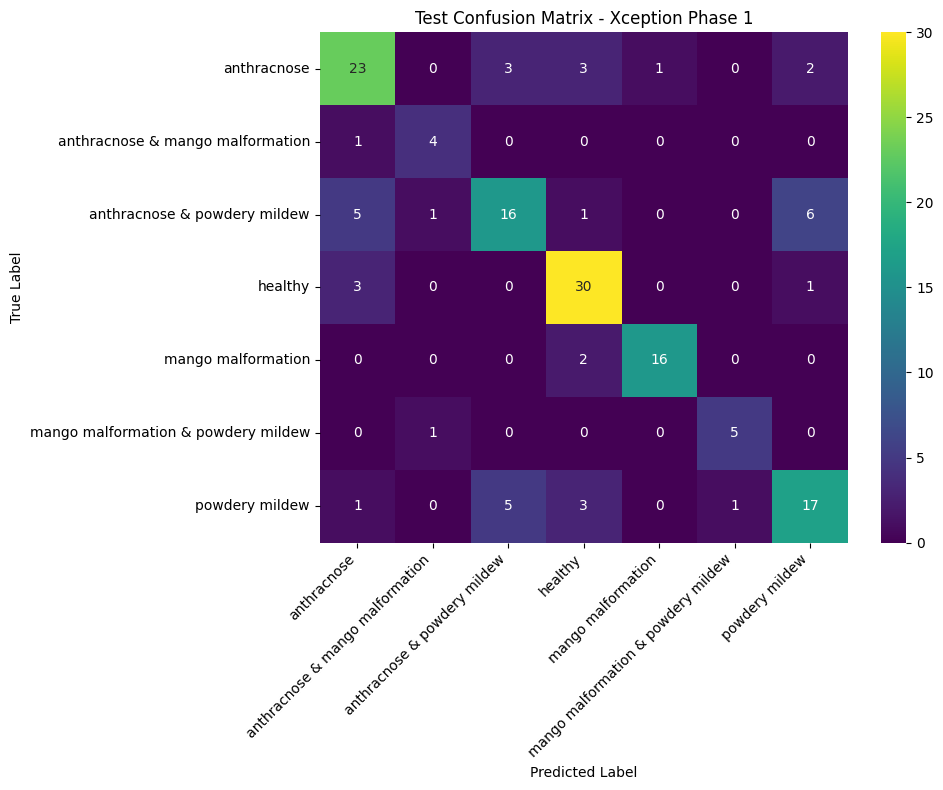

In [ ]:
# Get true test labels
y_true_test_xception = np.concatenate([
    y.numpy() for x, y in test_ds
])

# Get prediction probabilities
y_prob_test_xception = xception_model.predict(test_ds)

# Convert probabilities to class predictions
y_pred_test_xception = np.argmax(
    y_prob_test_xception,
    axis=1
)

# Create confusion matrix
cm_test_xception = confusion_matrix(
    y_true_test_xception,
    y_pred_test_xception
)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_test_xception,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Test Confusion Matrix - Xception Phase 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Xception Phase 1 - Test Classification Report\n")

print(
    classification_report(
        y_true_test_xception,
        y_pred_test_xception,
        target_names=class_names,
        digits=4
    )
)

Xception Phase 1 - Test Classification Report

                                     precision    recall  f1-score   support

                        anthracnose     0.6970    0.7188    0.7077        32
   anthracnose & mango malformation     0.6667    0.8000    0.7273         5
       anthracnose & powdery mildew     0.6667    0.5517    0.6038        29
                            healthy     0.7692    0.8824    0.8219        34
                 mango malformation     0.9412    0.8889    0.9143        18
mango malformation & powdery mildew     0.8333    0.8333    0.8333         6
                     powdery mildew     0.6538    0.6296    0.6415        27

                           accuracy                         0.7351       151
                          macro avg     0.7468    0.7578    0.7500       151
                       weighted avg     0.7332    0.7351    0.7319       151



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


In [ ]:
base_convnext = keras.applications.ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

base_convnext.trainable = False

print("ConvNeXtTiny loaded successfully.")

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
ConvNeXtTiny loaded successfully.


In [ ]:
model_convnext = keras.Sequential()

model_convnext.add(
    keras.Input(shape=(256, 256, 3))
)

model_convnext.add(
    data_augmentation
)

model_convnext.add(
    base_convnext
)

model_convnext.add(
    keras.layers.GlobalAveragePooling2D()
)

model_convnext.add(
    keras.layers.Dropout(0.3)
)

model_convnext.add(
    keras.layers.Dense(
        128,
        activation="relu"
    )
)

model_convnext.add(
    keras.layers.Dropout(0.2)
)

model_convnext.add(
    keras.layers.Dense(
        7,
        activation="softmax"
    )
)

model_convnext.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 8, 8, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,919,463 (106.50 MB)

 Trainable params: 99,335 (388.03 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

In [ ]:
model_convnext.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
convnext_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

convnext_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

convnext_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_convnext_tiny_phase1.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
print("Classes:", train_ds.class_names)

print(
    "Training batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_ds).numpy()
)

Classes: ['anthracnose', 'anthracnose & mango malformation', 'anthracnose & powdery mildew', 'healthy', 'mango malformation', 'mango malformation & powdery mildew', 'powdery mildew']
Training batches: 44
Validation batches: 5


In [ ]:
history_convnext = model_convnext.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[
        convnext_early_stopping,
        convnext_reduce_lr,
        convnext_checkpoint
    ]
)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3996s 89s/step - accuracy: 0.5036 - loss: 1.3572 - val_accuracy: 0.6187 - val_loss: 1.0237 - learning_rate: 0.0010
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3711s 84s/step - accuracy: 0.7229 - loss: 0.7840 - val_accuracy: 0.6978 - val_loss: 0.8225 - learning_rate: 0.0010
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3663s 83s/step - accuracy: 0.7821 - loss: 0.6085 - val_accuracy: 0.7122 - val_loss: 0.7684 - learning_rate: 0.0010
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3681s 84s/step - accuracy: 0.8250 - loss: 0.5177 - val_accuracy: 0.7338 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3584s 81s/step - accuracy: 0.8486 - loss: 0.4446 - val_accuracy: 0.7554 - val_loss: 0.6817 - learning_rate: 0.0010
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3712s 83s/step - accuracy: 0.8729 - loss: 0.3967 - val_accuracy: 0.7698 - val_loss: 0.6791 - learning_rate: 0.0010
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 3613s 82s/step - accuracy: 0.8871 - loss: 0.

In [ ]:
import os

checkpoint_path = "/content/drive/MyDrive/flower/mango_dataset/models/best_convnext_tiny_phase1.keras"

print("Checkpoint exists:", os.path.exists(checkpoint_path))

if os.path.exists(checkpoint_path):
    print("Checkpoint size:", round(os.path.getsize(checkpoint_path) / (1024**2), 2), "MB")

Checkpoint exists: True
Checkpoint size: 107.77 MB


In [ ]:
from tensorflow import keras

model_convnext = keras.models.load_model(
    checkpoint_path
)

print("ConvNeXtTiny checkpoint loaded successfully.")

ConvNeXtTiny checkpoint loaded successfully.


In [ ]:
history_convnext_resume = model_convnext.fit(
    train_ds,
    validation_data=validation_ds,
    initial_epoch=7,
    epochs=15,
    callbacks=[
        convnext_early_stopping,
        convnext_reduce_lr,
        convnext_checkpoint
    ]
)

Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 715s 16s/step - accuracy: 0.8879 - loss: 0.3145 - val_accuracy: 0.7554 - val_loss: 0.6754 - learning_rate: 0.0010
Epoch 9/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 185s 4s/step - accuracy: 0.9050 - loss: 0.2937 - val_accuracy: 0.7770 - val_loss: 0.6699 - learning_rate: 0.0010
Epoch 10/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.9036 - loss: 0.2709 - val_accuracy: 0.7770 - val_loss: 0.6290 - learning_rate: 0.0010
Epoch 11/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.9129 - loss: 0.2527 - val_accuracy: 0.7698 - val_loss: 0.6836 - learning_rate: 0.0010
Epoch 12/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.9171 - loss: 0.2468 - val_accuracy: 0.7842 - val_loss: 0.6237 - learning_rate: 0.0010
Epoch 13/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.9350 - loss: 0.2091 - val_accuracy: 0.7914 - val_loss: 0.6377 - learning_rate: 0.0010
Epoch 14/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.9357 - loss: 0.1934 - v

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

convnext_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="convnext_augmentation")

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

base_convnext = keras.applications.ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

base_convnext.trainable = False

model_convnext_reg = keras.Sequential([

    keras.Input(shape=(256, 256, 3)),

    convnext_augmentation,

    base_convnext,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.50),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.30),

    layers.Dense(
        7,
        activation="softmax"
    )
])

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
import tensorflow as tf
from tensorflow import keras

# Label smoothing loss for integer labels
categorical_loss = keras.losses.CategoricalCrossentropy(
    label_smoothing=0.05
)

def sparse_loss_with_label_smoothing(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_true = tf.one_hot(y_true, depth=7)

    return categorical_loss(y_true, y_pred)


model_convnext_reg.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=3e-4
    ),

    loss=sparse_loss_with_label_smoothing,

    metrics=["accuracy"]
)

In [ ]:
convnext_reg_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

convnext_reg_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

convnext_reg_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_convnext_tiny_regularized.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
history_convnext_reg = model_convnext_reg.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[
        convnext_reg_early_stopping,
        convnext_reg_reduce_lr,
        convnext_reg_checkpoint
    ]
)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 731s 16s/step - accuracy: 0.1964 - loss: 2.1077 - val_accuracy: 0.3165 - val_loss: 1.7925 - learning_rate: 3.0000e-04
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 200s 5s/step - accuracy: 0.2779 - loss: 1.8153 - val_accuracy: 0.3597 - val_loss: 1.6741 - learning_rate: 3.0000e-04
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.3636 - loss: 1.6670 - val_accuracy: 0.4317 - val_loss: 1.5761 - learning_rate: 3.0000e-04
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 192s 4s/step - accuracy: 0.4629 - loss: 1.4981 - val_accuracy: 0.4604 - val_loss: 1.4621 - learning_rate: 3.0000e-04
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.4757 - loss: 1.4303 - val_accuracy: 0.4892 - val_loss: 1.3870 - learning_rate: 3.0000e-04
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.5457 - loss: 1.3198 - val_accuracy: 0.5252 - val_loss: 1.3251 - learning_rate: 3.0000e-04
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.5807

In [ ]:
model_convnext_reg = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_convnext_tiny_regularized.keras",
    custom_objects={
        "sparse_loss_with_label_smoothing": sparse_loss_with_label_smoothing
    }
)

In [ ]:
model_convnext_reg.evaluate(validation_ds)

5/5 ━━━━━━━━━━━━━━━━━━━━ 346s 61s/step - accuracy: 0.5971 - loss: 1.1633


[1.1632747650146484, 0.597122311592102]

In [ ]:
history_convnext_reg_more = model_convnext_reg.fit(
    train_ds,
    validation_data=validation_ds,
    initial_epoch=15,
    epochs=25,
    callbacks=[
        convnext_reg_early_stopping,
        convnext_reg_reduce_lr,
        convnext_reg_checkpoint
    ]
)

Epoch 16/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3428s 77s/step - accuracy: 0.6929 - loss: 0.9879 - val_accuracy: 0.5827 - val_loss: 1.1640 - learning_rate: 3.0000e-04
Epoch 17/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3371s 76s/step - accuracy: 0.7007 - loss: 0.9477 - val_accuracy: 0.5683 - val_loss: 1.1642 - learning_rate: 3.0000e-04
Epoch 18/25
19/44 ━━━━━━━━━━━━━━━━━━━━ 29:34 71s/step - accuracy: 0.6864 - loss: 0.9829

Fine tunning phase 1 model

In [ ]:
best_model = keras.models.load_model(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_phase1_model.keras"
)

base_model = best_model.get_layer("efficientnetv2-b0")

print("Total backbone layers:", len(base_model.layers))

Total backbone layers: 270


In [ ]:
# Freeze the entire EfficientNetV2B0 backbone first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last 20 layers
# Keep BatchNormalization layers frozen
for layer in base_model.layers[-20:]:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

# Check how many layers are trainable
trainable_layers = sum(layer.trainable for layer in base_model.layers)

print("Total backbone layers:", len(base_model.layers))
print("Trainable backbone layers:", trainable_layers)

Total backbone layers: 270
Trainable backbone layers: 16


In [ ]:
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
fine_tune_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2b0_finetune_20layers.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

fine_tune_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks ready.")

Callbacks ready.


In [ ]:
history_finetune_20 = best_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ]
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9455 - loss: 0.1744
Epoch 1: val_loss improved from None to 0.46871, saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2b0_finetune_20layers.keras

Epoch 1: finished saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2b0_finetune_20layers.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 363s 8s/step - accuracy: 0.9393 - loss: 0.1707 - val_accuracy: 0.8561 - val_loss: 0.4687 - learning_rate: 1.0000e-05
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9393 - loss: 0.1729
Epoch 2: val_loss did not improve from 0.46871
44/44 ━━━━━━━━━━━━━━━━━━━━ 329s 7s/step - accuracy: 0.9421 - loss: 0.1747 - val_accuracy: 0.8561 - val_loss: 0.4742 - learning_rate: 1.0000e-05
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9437 - loss: 0.1573
Epoch 3: val_loss did not improve from 0.46871

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-0

Next variant EfficientNetV2M

In [ ]:
base_v2m = keras.applications.EfficientNetV2M(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

base_v2m.trainable = False

print("EfficientNetV2M loaded successfully.")
print("Total backbone layers:", len(base_v2m.layers))

214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
EfficientNetV2M loaded successfully.
Total backbone layers: 740


In [ ]:
model_v2m = keras.Sequential([
    keras.Input(shape=(256, 256, 3)),
    data_augmentation,
    base_v2m,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(7, activation="softmax")
])

model_v2m.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 8, 8, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,315,259 (203.38 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

In [ ]:
model_v2m.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("EfficientNetV2M compiled successfully.")

EfficientNetV2M compiled successfully.


In [ ]:
v2m_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2m_phase1.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

v2m_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

v2m_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("EfficientNetV2M callbacks ready.")

EfficientNetV2M callbacks ready.


In [ ]:
history_v2m = model_v2m.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[
        v2m_checkpoint,
        v2m_early_stopping,
        v2m_reduce_lr
    ]
)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.3328 - loss: 1.6967 
Epoch 1: val_loss improved from None to 1.14371, saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2m_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2m_phase1.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 885s 19s/step - accuracy: 0.4507 - loss: 1.4680 - val_accuracy: 0.5180 - val_loss: 1.1437 - learning_rate: 0.0010
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.6421 - loss: 0.9729 
Epoch 2: val_loss improved from 1.14371 to 0.97620, saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2m_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/flower/mango_dataset/models/best_efficientnetv2m_phase1.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 849s 19s/step - accuracy: 0.6736 - loss: 0.9092 - val_accuracy: 0.6043 - val_loss: 0.9762 - learning_rate: 0.0010
Epoch

In [2]:
from tensorflow import keras
keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet"
)

I0000 00:00:1790016328.279969    2012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790016328.615029    2012 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790016330.056914    2012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1790016331.058518    2012 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute c

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


<Functional name=efficientnetv2-b0, built=True>